# LES Intercomparison Study for CBL: SGS Model Coefficients

*Last updated: May 2026*


For case setup and physical parameters, see the [Description](CBL_N91_Description.ipynb) notebook.

Vertical profiles of the SGS coefficients — Smagorinsky coefficient $C_s$, SGS Prandtl number $\mathrm{Pr}_{SGS}$, and scale-dependence parameters $\beta_1$ (momentum) and $\beta_2$ (scalar) — are compared across the four grid resolutions ($64^3$, $128^3$, $256^3$, $384^3$) for a user-selected SGS model.

## Setup

The next cells load Python packages, locate the simulation outputs, and define the grid and averaging window used throughout the notebook.

In [78]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Output directories

In [79]:
from pathlib import Path

# Base directory (JAXALFA0.1/)
def find_repo_root(start=None):
    path = Path(start or ('__file__' in globals() and __file__) or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'examples').is_dir() and (candidate / 'docs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate JAXALFA0.1 repository root')

BaseDir = find_repo_root()

def read_config(run_dir):
    cfg = {}
    exec((run_dir / 'Config.py').read_text(), cfg)
    return cfg


optSGS = 1  # LASDD-SM: 1, LASDD-WL: 2, LAD-SM: 3, LAD-WL: 4

sgs_names = {1: 'LASDD-SM', 2: 'LASDD-WL', 3: 'LAD-SM', 4: 'LAD-WL'}

run_styles = {
    '64x64x64':         {'color': 'red',   'linestyle': '-'},
    '128x128x128':      {'color': 'blue',  'linestyle': '-'},
    '256x256x256':      {'color': 'green', 'linestyle': '-'},
    '384x384x384 (SP)': {'color': 'black', 'linestyle': '-'},
}

_sgs = {1: 'LASDD_SM', 2: 'LASDD_WL', 3: 'LAD_SM', 4: 'LAD_WL'}
OutputDir1 = BaseDir / f'examples/CBL_N91/runs/64x64x64_{_sgs[optSGS]}_DP/output'
OutputDir2 = BaseDir / f'examples/CBL_N91/runs/128x128x128_{_sgs[optSGS]}_DP/output'
OutputDir3 = BaseDir / f'examples/CBL_N91/runs/256x256x256_{_sgs[optSGS]}_DP/output'
OutputDir4 = BaseDir / f'examples/CBL_N91/runs/384x384x384_{_sgs[optSGS]}_SP/output'

### Case configuration

In [80]:
cfg_1 = read_config(OutputDir1.parent)
cfg_2 = read_config(OutputDir2.parent)
cfg_3 = read_config(OutputDir3.parent)
cfg_4 = read_config(OutputDir4.parent)

nz_1 = int(cfg_1['nz'])
nz_2 = int(cfg_2['nz'])
nz_3 = int(cfg_3['nz'])
nz_4 = int(cfg_4['nz'])

l_z = float(cfg_1['l_z'])
z_damping = float(cfg_1.get('z_damping', np.nan))
OutputInterval_sec = float(cfg_1.get('OutputInterval_sec', 60.0))

# Averaging window — CBL quasi-steady state (hours 3.0-3.5)
T_start = 3.0 * 3600   # s
T_end   = 3.5 * 3600   # s

### Derived grid and averaging indices

In [81]:
# Half levels — SGS coefficients live at UVP nodes
z_1 = np.array([(k + 0.5) * l_z / (nz_1 - 1) for k in range(nz_1)])
z_2 = np.array([(k + 0.5) * l_z / (nz_2 - 1) for k in range(nz_2)])
z_3 = np.array([(k + 0.5) * l_z / (nz_3 - 1) for k in range(nz_3)])
z_4 = np.array([(k + 0.5) * l_z / (nz_4 - 1) for k in range(nz_4)])

# File indices for the averaging window
T_start_index = int(T_start / OutputInterval_sec) - 1
T_end_index   = int(T_end   / OutputInterval_sec) - 1

print(f'Averaging window: file indices {T_start_index} – {T_end_index}')

Averaging window: file indices 179 – 209


### SGS coefficient loader

In [82]:
def LoadSGSAverage(stat_files, T_start_index, T_end_index, nz_expected):
    """Return time-averaged SGS coefficient profiles over the given window.

    Returns
    -------
    Cs2_1, Cs2_2 : ndarray (nz)
        Smagorinsky coefficient squared: (PlanarMean(Cs))^2 and PlanarMean(Cs^2).
    Cs2PrRatio : ndarray (nz)
        PlanarMean(Cs^2 / Pr_T) profile.
    Beta1, Beta2 : ndarray (nz)
        Scale-dependence parameters for momentum and scalar.
    """
    if len(stat_files) == 0:
        print(f'No statistics files available; plotting NaN placeholders for nz={nz_expected}.')
        nan = np.full(nz_expected, np.nan)
        return nan, nan.copy(), nan.copy(), nan.copy(), nan.copy()

    sl = slice(T_start_index, min(T_end_index + 1, len(stat_files)))
    if sl.start >= len(stat_files):
        print(f'Averaging window starts after available files; plotting NaN placeholders for nz={nz_expected}.')
        nan = np.full(nz_expected, np.nan)
        return nan, nan.copy(), nan.copy(), nan.copy(), nan.copy()

    Cs2_1_list = []; Cs2_2_list = []; Cs2PR_list = []
    B1_list    = []; B2_list    = []

    for f in stat_files[sl]:
        with np.load(f) as d:
            Cs2_1_list.append(d['Cs2_1'])
            Cs2_2_list.append(d['Cs2_2'])
            Cs2PR_list.append(d['Cs2PrRatio'])
            B1_list.append(d['Beta1'])
            B2_list.append(d['Beta2'])

    return (
        np.mean(Cs2_1_list, axis=0),
        np.mean(Cs2_2_list, axis=0),
        np.mean(Cs2PR_list, axis=0),
        np.mean(B1_list,    axis=0),
        np.mean(B2_list,    axis=0),
    )


### Available statistics files

In [83]:
def get_stat_files(output_dir):
    files = sorted(
        glob.glob(str(output_dir / 'ALFA_Statistics_Iteration_*.npz')),
        key=lambda x: int(re.search(r'Iteration_(\d+)', x).group(1))
    )
    return files

StatFiles1 = get_stat_files(OutputDir1)
StatFiles2 = get_stat_files(OutputDir2)
StatFiles3 = get_stat_files(OutputDir3)
StatFiles4 = get_stat_files(OutputDir4)

print(f'64^3  : {len(StatFiles1)} files')
print(f'128^3 : {len(StatFiles2)} files')
print(f'256^3 : {len(StatFiles3)} files')
print(f'384^3 : {len(StatFiles4)} files')

64^3  : 210 files
128^3 : 210 files
256^3 : 210 files
384^3 : 210 files


### Temporally averaged profiles

In [84]:
(Cs2_1_avg_1, Cs2_2_avg_1, Cs2PR_avg_1, B1_avg_1, B2_avg_1) = \
    LoadSGSAverage(StatFiles1, T_start_index, T_end_index, nz_1)

(Cs2_1_avg_2, Cs2_2_avg_2, Cs2PR_avg_2, B1_avg_2, B2_avg_2) = \
    LoadSGSAverage(StatFiles2, T_start_index, T_end_index, nz_2)

(Cs2_1_avg_3, Cs2_2_avg_3, Cs2PR_avg_3, B1_avg_3, B2_avg_3) = \
    LoadSGSAverage(StatFiles3, T_start_index, T_end_index, nz_3)

(Cs2_1_avg_4, Cs2_2_avg_4, Cs2PR_avg_4, B1_avg_4, B2_avg_4) = \
    LoadSGSAverage(StatFiles4, T_start_index, T_end_index, nz_4)

# SGS coefficient: two averaging conventions
# Method 1: C = PlanarMean(C), then squared for storage → take sqrt
# Method 2: C = sqrt(PlanarMean(C^2))
Cs_m1_1 = np.sqrt(np.abs(Cs2_1_avg_1));  Cs_m2_1 = np.sqrt(np.abs(Cs2_2_avg_1))
Cs_m1_2 = np.sqrt(np.abs(Cs2_1_avg_2));  Cs_m2_2 = np.sqrt(np.abs(Cs2_2_avg_2))
Cs_m1_3 = np.sqrt(np.abs(Cs2_1_avg_3));  Cs_m2_3 = np.sqrt(np.abs(Cs2_2_avg_3))
Cs_m1_4 = np.sqrt(np.abs(Cs2_1_avg_4));  Cs_m2_4 = np.sqrt(np.abs(Cs2_2_avg_4))

# PrSGS = Cs2_2 / Cs2PrRatio  (NaN where Cs2PrRatio ≈ 0)
_tol = 1e-10
PrSGS_1 = np.where(Cs2PR_avg_1 > _tol, Cs2_2_avg_1 / Cs2PR_avg_1, np.nan)
PrSGS_2 = np.where(Cs2PR_avg_2 > _tol, Cs2_2_avg_2 / Cs2PR_avg_2, np.nan)
PrSGS_3 = np.where(Cs2PR_avg_3 > _tol, Cs2_2_avg_3 / Cs2PR_avg_3, np.nan)
PrSGS_4 = np.where(Cs2PR_avg_4 > _tol, Cs2_2_avg_4 / Cs2PR_avg_4, np.nan)

print(f'Averaging over {T_end_index - T_start_index + 1} files '
      f'({T_start/3600:.1f}–1{T_end/3600:.1f} h)')

Averaging over 31 files (3.0–13.5 h)


In [85]:
plt.rcParams.update({
    "text.usetex": True,
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

## SGS Model Coefficient

For SM variants (LASDD-SM, LAD-SM) the coefficient is the Smagorinsky coefficient $C_s$; for WL variants (LASDD-WL, LAD-WL) it is the Wong-Lilly SGS coefficient $C$. Two planar-averaging conventions are shown:
- **Method 1** (left): $C = \langle C \rangle_{xy}$ — planar mean of the pointwise field.
- **Method 2** (right): $C = \sqrt{\langle C^2 \rangle_{xy}}$ — root of the planar mean of $C^2$.

By Jensen's inequality, Method 2 $\geq$ Method 1.

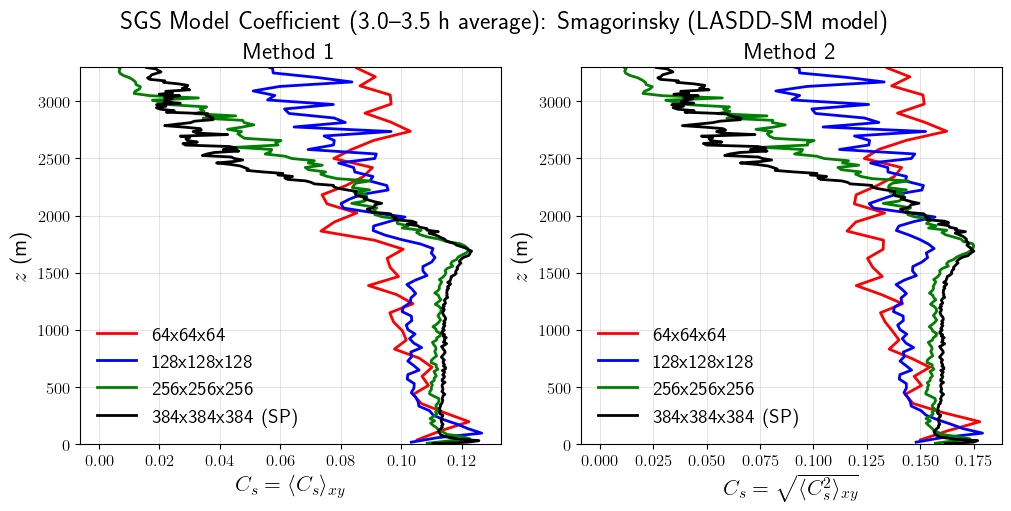

In [86]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

_coeff_sym  = r'C_s' if optSGS in [1, 3] else r'C'
_coeff_name = 'Smagorinsky' if optSGS in [1, 3] else 'Wong-Lilly SGS'

for lbl, Cs_m1, Cs_m2, z in [
    ('64x64x64', Cs_m1_1, Cs_m2_1, z_1),
    ('128x128x128', Cs_m1_2, Cs_m2_2, z_2),
    ('256x256x256', Cs_m1_3, Cs_m2_3, z_3),
    ('384x384x384 (SP)', Cs_m1_4, Cs_m2_4, z_4),
]:
    style = run_styles[lbl]
    axs[0].plot(Cs_m1, z, color=style['color'], linestyle=style['linestyle'], linewidth=2, label=lbl)
    axs[1].plot(Cs_m2, z, color=style['color'], linestyle=style['linestyle'], linewidth=2, label=lbl)

axs[0].set_xlabel(rf"${_coeff_sym} = \langle {_coeff_sym} \rangle_{{xy}}$")
axs[0].set_ylabel(r"$z$ (m)")
axs[0].set_title("Method 1")

axs[1].set_xlabel(rf"${_coeff_sym} = \sqrt{{\langle {_coeff_sym}^2 \rangle_{{xy}}}}$")
axs[1].set_ylabel(r"$z$ (m)")
axs[1].set_title("Method 2")

for ax in axs:
    ax.set_ylim(0, z_damping)
    ax.grid()
    ax.legend(frameon=False)

fig.suptitle(f"SGS Model Coefficient (3.0--3.5 h average): {_coeff_name} ({sgs_names[optSGS]} model)", fontsize=18)
plt.show()

## SGS Prandtl Number

The SGS Prandtl number is derived from the stored $\langle C^2 \rangle_{xy}$ and $\langle C^2/\mathrm{Pr}_\mathrm{SGS} \rangle_{xy}$ profiles:
$$\mathrm{Pr}_\mathrm{SGS}(z) = \frac{\langle C^2 \rangle_{xy}}{\langle C^2/\mathrm{Pr}_\mathrm{SGS} \rangle_{xy}}$$
where $\langle C^2 \rangle_{xy}$ is Method 2 (root-mean-square planar average). Both numerator and denominator are planar means of pointwise 3D fields, making their ratio consistent. Points where $\langle C^2/\mathrm{Pr}_\mathrm{SGS} \rangle_{xy} < 10^{-10}$ or $\mathrm{Pr}_\mathrm{SGS} > \mathrm{Pr}_{\mathrm{SGS},\mathrm{max}}$ are masked.

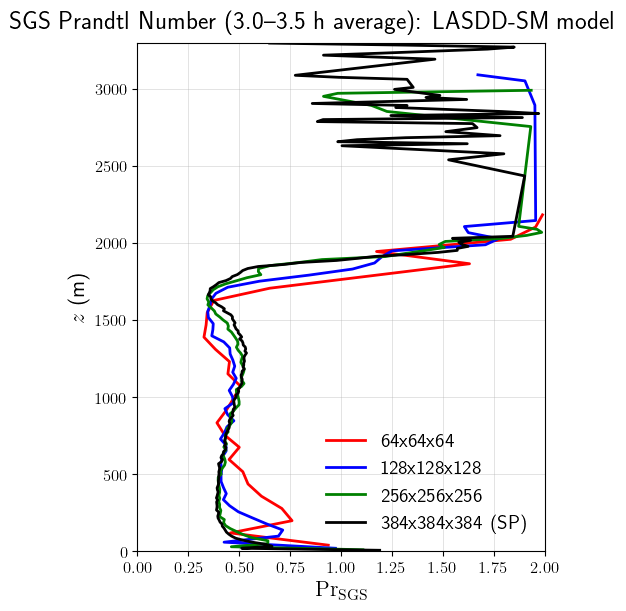

In [87]:
fig, ax = plt.subplots(figsize=(5, 6), constrained_layout=True)

PrSGS_xlim = 2.0  # adjust if needed

for lbl, PrSGS, z in [
    ('64x64x64', PrSGS_1, z_1),
    ('128x128x128', PrSGS_2, z_2),
    ('256x256x256', PrSGS_3, z_3),
    ('384x384x384 (SP)', PrSGS_4, z_4),
]:
    style = run_styles[lbl]
    mask = (z <= z_damping) & (PrSGS <= PrSGS_xlim)
    ax.plot(PrSGS[mask], z[mask], color=style['color'], linestyle=style['linestyle'], linewidth=2, label=lbl)

ax.set_xlabel(r"$\mathrm{Pr}_\mathrm{SGS}$")
ax.set_ylabel(r"$z$ (m)")
ax.set_xlim(0, PrSGS_xlim)
ax.set_ylim(0, z_damping)
ax.grid()
ax.legend(frameon=False)

fig.suptitle(f"SGS Prandtl Number (3.0--3.5 h average): {sgs_names[optSGS]} model", fontsize=18)
plt.show()

## Scale-dependence Parameters

The scale-dependence parameters $\beta_1$ (momentum) and $\beta_2$ (scalar) characterize how the dynamic coefficient varies across filter scales. Values near unity indicate weak scale dependence; departures signal the model adapting to local turbulence structure.

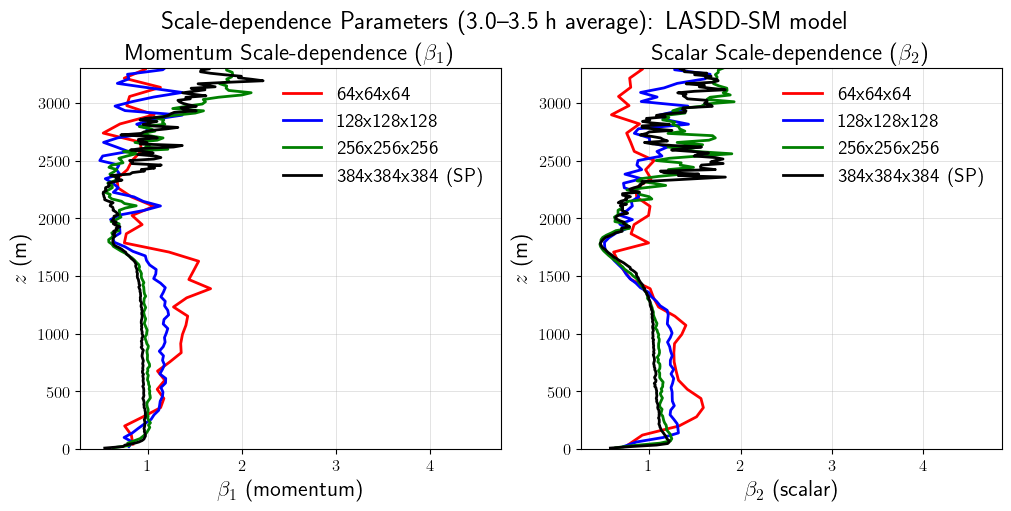

In [88]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

for lbl, B1, B2, z in [
    ('64x64x64',         B1_avg_1, B2_avg_1, z_1),
    ('128x128x128',      B1_avg_2, B2_avg_2, z_2),
    ('256x256x256',      B1_avg_3, B2_avg_3, z_3),
    ('384x384x384 (SP)', B1_avg_4, B2_avg_4, z_4),
]:
    style = run_styles[lbl]
    axs[0].plot(B1, z, color=style['color'], linestyle=style['linestyle'], linewidth=2, label=lbl)
    axs[1].plot(B2, z, color=style['color'], linestyle=style['linestyle'], linewidth=2, label=lbl)

axs[0].set_xlabel(r"$\beta_1$ (momentum)")
axs[0].set_ylabel(r"$z$ (m)")
axs[0].set_title(r"Momentum Scale-dependence ($\beta_1$)")

axs[1].set_xlabel(r"$\beta_2$ (scalar)")
axs[1].set_ylabel(r"$z$ (m)")
axs[1].set_title(r"Scalar Scale-dependence ($\beta_2$)")

for ax in axs:
    ax.set_ylim(0, z_damping)
    ax.grid()
    ax.legend(frameon=False)

fig.suptitle(f"Scale-dependence Parameters (3.0--3.5 h average): {sgs_names[optSGS]} model", fontsize=18)
plt.show()